<a href="https://colab.research.google.com/github/Jake0925/DeepLearning/blob/master/%EC%95%A4%EB%93%9C%EB%A5%98_2%EC%A3%BC%EC%B0%A8_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C2_%EC%8B%A0%EA%B2%BD%EB%A7%9D%EC%82%AC%EA%B3%A0%EB%B0%A9%EC%8B%9D%EC%9D%84%EC%9D%B4%EC%9A%A9%ED%95%9C%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1%ED%9A%8C%EA%B7%80%EB%AA%A8%EB%8D%B8%EB%A7%8C%EB%93%A4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://medium.com/@mikeolugbenle/logistics-regression-with-neural-network-mindset-66d0d7e91d9f

https://github.com/HeroKillerEver/coursera-deep-learning/blob/master/Neural%20Networks%20and%20Deep%20Learning/Logistic%20Regression%20as%20a%20Neural%20Network/Logistic%2BRegression%2Bwith%2Ba%2BNeural%2BNetwork%2Bmindset%2Bv5.ipynb

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import h5py #  a common package to interact with a dataset that is stored on an H5 file.
import scipy
from PIL import Image
from scipy import ndimage
# from lr_utils import load_dataset # coursera에서 다운받아야하는파일이지만 없는관계로 아래와 같이 함수를 만들어준다

%matplotlib inline

In [77]:
from google.colab import drive
drive.mount('/content/drive')
trainset = '/content/drive/MyDrive/dataset/train_catvnoncat.h5'
testset = '/content/drive/MyDrive/dataset/test_catvnoncat.h5'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
# def load_dataset():
#     with h5py.File('datasets/train_catvnoncat.h5', "r") as train_dataset:
#         train_set_x_orig = np.array(train_dataset["train_set_x"][:])
#         train_set_y_orig = np.array(train_dataset["train_set_y"][:])

#     with h5py.File('datasets/test_catvnoncat.h5', "r") as test_dataset:
#         test_set_x_orig = np.array(test_dataset["test_set_x"][:])
#         test_set_y_orig = np.array(test_dataset["test_set_y"][:])
#         classes = np.array(test_dataset["list_classes"][:])

#     # 채널이3개인 3차원이미지를 1차원으로 변환
#     train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
#     test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

#     return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [79]:
def load_dataset():
    train_ds = h5py.File(trainset, 'r')
    # train_ds = h5py.File('datasets/train_catvnoncat.h5', 'r')
    train_set_x = np.array(train_ds['train_set_x'][:])
    train_set_y = np.array(train_ds['train_set_y'][:])

    test_ds = h5py.File(testset, 'r')
    # test_ds = h5py.File('datasets/test_catvnoncat.h5', 'r')
    test_set_x = np.array(test_ds['test_set_x'][:])
    test_set_y = np.array(test_ds['test_set_y'][:])

    classes = np.array(test_ds['list_classes'][:])

    train_set_y = train_set_y.reshape((1, train_set_y.shape[0]))
    test_set_y = test_set_y.reshape((1, test_set_y.shape[0]))



    return train_set_x, train_set_y, test_set_x, test_set_y, classes

In [80]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

np.squeeze - 축중에서 1의값을 갖는 축을 제거해준다

y = [0], it's a 'non-cat' picture.


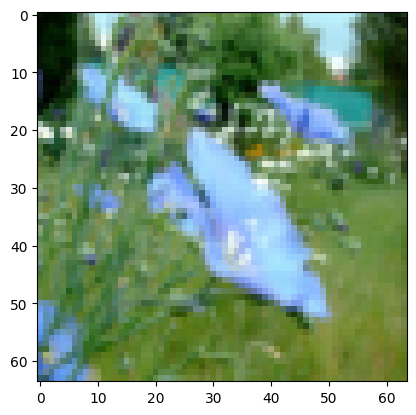

In [81]:
index = 20
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

array([[[17, 31, 56],
        [22, 33, 59],
        [25, 35, 62],
        ...,
        [ 1, 28, 57],
        [ 1, 26, 56],
        [ 1, 22, 51]],

       [[25, 36, 62],
        [28, 38, 64],
        [30, 40, 67],
        ...,
        [ 1, 27, 56],
        [ 1, 25, 55],
        [ 2, 21, 51]],

       [[32, 40, 67],
        [34, 42, 69],
        [35, 42, 70],
        ...,
        [ 1, 25, 55],
        [ 0, 24, 54],
        [ 1, 21, 51]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)
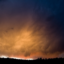

In [82]:
train_set_x_orig[0]

In [83]:
train_set_y[0]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

Exercise: Find the values for:

- m_train (number of training examples)

- m_test (number of test examples)

- num_px (= height = width of a training image)

Remember that train_set_x_orig is a numpy-array of shape (m_train, num_px, num_px, 3).

For instance, you can access m_train by writing train_set_x_orig.shape[0].

In [84]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1] * train_set_x_orig.shape[2] # 행과 열의 곱

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x shape: " + str(train_set_x_orig.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 4096
Each image is of size: (4096, 4096, 3)
train_set_x shape: (209, 64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


Exercise:

- 64 * 64 * 3의 이미지를 1차원으로 만들어라


- 아래 공식은 a축을 제외한 나머지 축을 1차원으로 만들어준다
- X(입력)의 모양은 (a,b,c,d)의 매트릭스이다. 이것을(b * c * d, a)형태로 만들어라
- X_flatten = X.reshape(X.shape[0], -1).T --->  (X.T는 X의 전치)

In [85]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T


print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))
print ("sanity check after reshaping: " + str(train_set_x_flatten[0:5,0]))

train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)
sanity check after reshaping: [17 31 56 22 33]


데이터셋 표준화


데이터셋을 전처리하는 일반적인 단계는 다음과 같습니다:
1.   문제의 차원과 형태를 파악합니다 (m_train, m_test, num_px, ...)
2.   각 예제가 (num_px * num_px * 3, 1) 크기의 벡터가 되도록 데이터 세트를 재구성합니다




이것을 데이터를 "표준화"한다라고 한다


In [86]:
train_set_x = train_set_x_flatten/255.
test_set_x = test_set_x_flatten/255.

# 학습 알고리즘의 일반 아키텍처

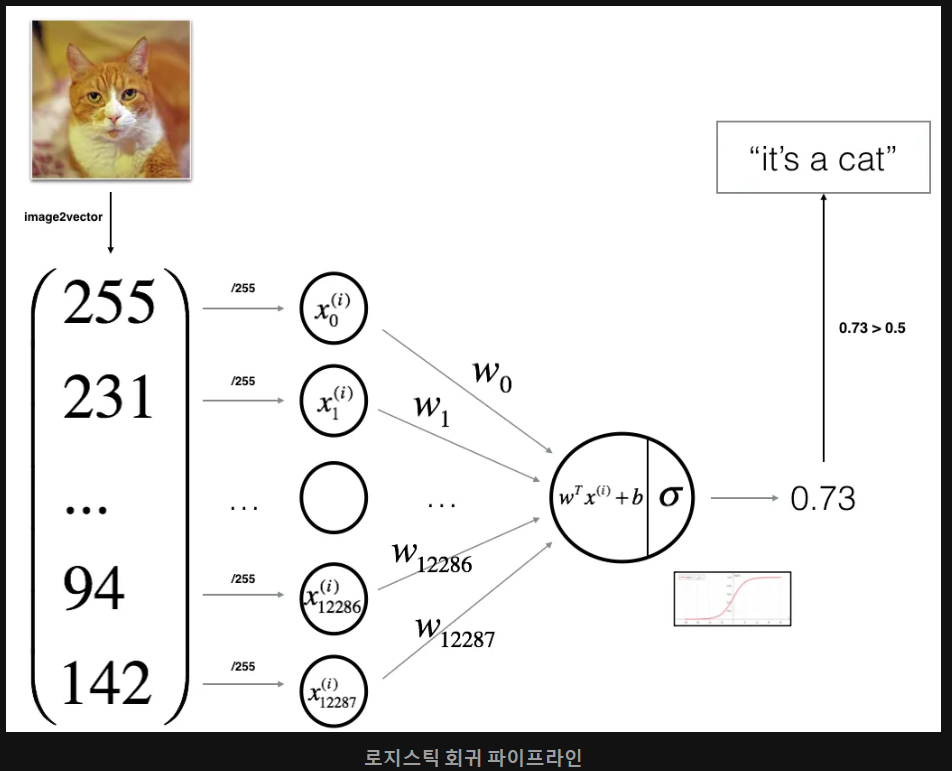

- 뉴런 - 딥 러닝에서 뉴런(위 이미지의 원 안에 wx + b가 있는 경우)은 인간 뇌 내부의 뉴런을 생물학적으로 영감을 받아 표현한 것입니다. 인간 뇌의 뉴런과 유사하게 인공 뉴런은 다른 뉴런으로부터 입력을 받아 다음 인공 뉴런 세트에 값을 발사합니다. "단일 뉴런 내부에서 두 가지 계산이 수행됩니다. 가중치 및 활성화."

- 가중 합 - 인공 뉴런에 대한 모든 입력 값 x 에는 가중치 w가 첨부되어 있으며, 이는 다른 입력과 관련된 해당 입력의 상대적 중요도를 알려줍니다. 각 가중치는 해당 입력과 곱해지고 합산되어 단일 값 z를 생성합니다.

- 활성화 - 가중 합 z를 계산한 후, 활성화 함수 a=g(z)가 이 가중 합 z에 적용됩니다. 활성화 함수는 비선형성을 도입하여 입력 값을 출력 값으로 변환하는 간단한 수학적 변환입니다. 이는 실제 입력이 비선형이고 신경망이 이 비선형성을 어떻게든 학습해야 하기 때문에 필요합니다.



로지스틱 회귀 개념: 이는 모델 알고리즘을 구축하기 위해 수행할 단계입니다.

1. 가중치 w와 편향 b를 무작위 값(예를 들어 0 또는 무작위 분포 사용)으로 초기화합니다.
2. 데이터 세트의 각 교육 샘플에 대해

- 입력 샘플 x(i) 에 대한 출력 값 a(i) 를 계산합니다 .
- 첫째: 가중 합 z(i)를 구합니다 .
- 두 번째: 가중 합 z(i) 에 대한 활성화 값 a(i) = y′(i) = g(z(i))를 계산합니다 .
- 이 입력 학습 샘플 y(i)에 대한 실제 라벨을 알고 있으므로 이를 사용하여 손실 L(a(i),y(i))을 찾습니다 .

3. 모든 손실의 합을 훈련 예제 수 mm로 나눈 값인 비용 함수 J를 계산합니다. 즉, 1m∑L(a(i),y(i)).


4. 비용 함수를 최소화하려면 미적분학의 연쇄 법칙을 사용하여 매개변수 dJ/dw 및 dJ/db에 대한 기울기를 계산합니다.

5. 경사 하강법을 사용하여 매개변수 w와 b를 업데이트합니다.

6. 비용 함수가 최소가 될 때까지 위의 절차를 수행합니다.



우리 알고리즘에 대한 수학적 표현 :

1. i번째 훈련 예제의 가중 합: z(i)=wT x(i)+b .
   (여기서 “.T”는 전치를 의미합니다.)

2. 시그모이드를 이용한 제1 훈련 예제 활성화

- y′(i) = a(i) = σ(z(i)) = 1/1+e−z(i)

3. 이 번째 훈련 예제 의 손실 함수

- L(a(i),y(i)) = −y(i)log(a(i))−(1−y(i))log(1−a(i)))

4. 모든 훈련 예제에 대한 비용 함수

- J = 1/m*∑L(a(i),y(i))

- J = −1/m*∑y(i)log(a(i))+(1−y(i))log(1−a(i)))

5. 비용 함수, 가중치 및 편향에 대한 경사 하강

- dJ/dw = 1/m*X(A−Y).T

- dJ/db=1/m*∑(a(i)−y(i))

6. 매개변수 업데이트 규칙

- w = w − α * dJ / dw

- b = b − α * dJ/db

참고로, 벡터화를 구현할 것입니다. 즉, 각 209개의 학습 예제를 반복하는 대신, 속도를 늦추기 위해 numpy 라이브러리를 사용하여 이를 결합할 것입니다. 아래 이미지는 numpy 배열의 차원이 어떤지 더 잘 이해할 수 있게 해줄 것입니다.

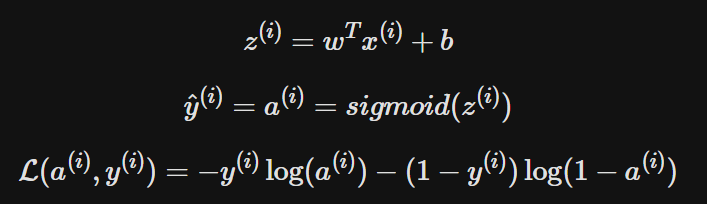

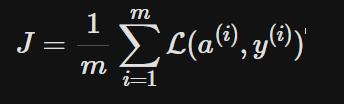

# 신경망 구축

1. 모델 구조(예: 입력 특징의 수)를 정의합니다
2. 모델의 매개변수 초기화
3. 루프:
- 현재 손실 계산(순방향 전파)
- 전류 기울기 계산(역방향 전파)
- 매개변수 업데이트(경사 하강법)


종종 1-3을 따로 만들어 모델()이라고 부르는 하나의 함수에 통합합니다.

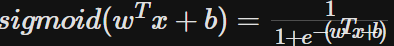

In [87]:
def sigmoid(z):

    s = 1 / (1 + np.exp(-z)) # 각요소에 대해 연산

    return s

In [88]:
print ("sigmoid([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid([0, 2]) = [0.5        0.88079708]


# 가중치 w와 편향 b를 0으로 초기화합니다

- For image inputs, w will be of shape (num_px
 num_px
 3, 1).

## assert

assert는 파이썬에서 조건을 검사하고, 조건이 False일 경우 AssertionError를 발생시키는 구문입니다. 주로 디버깅을 위해 사용되며, 예상되는 조건이 참인지 확인하는 데 유용합니다.

- assert 조건, "조건이 False일 때 출력할 메시지"
- assert는 프로그램이 실행될 때 조건이 False인 경우에만 AssertionError를 발생시키므로, 조건이 항상 True가 되어야 하는 부분에 사용하면 유용합니다.

In [89]:
def initialize_with_zeros(dim):
  w = np.zeros((dim, 1)) # dim행 1열의 0의 값인 배열생성
  b = 0

  assert(w.shape == (dim, 1))
  assert(isinstance(b, float) or isinstance(b, int))

  return w, b

In [90]:
dim = 2
w, b = initialize_with_zeros(dim)
print ("w = " + str(w))
print ("b = " + str(b))

w = [[0.]
 [0.]]
b = 0


# 순전파와 역전파 (Forward and Backward propagation)

- dw, db값을 구한다

- 연습: 비용 함수와 그 기울기를 계산하는 함수 전파()를 구현합니다

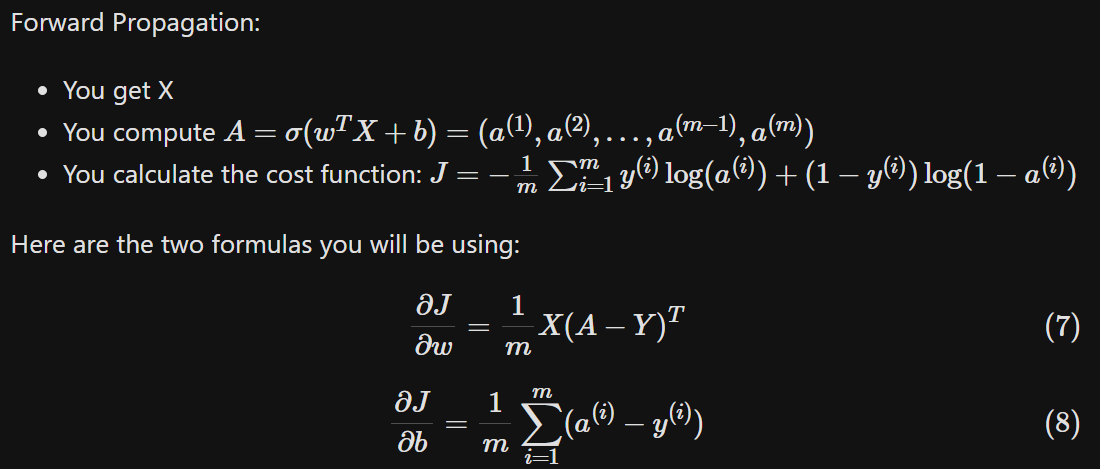

직접구현

In [91]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1., 2., -1.],[3., 4., -3.2]]), np.array([[1,0,1]])

# 각 요소별 가설연산
Y_mul = w*X
print (Y_mul)
Y_hat = Y_mul[0] + Y_mul[1] + b # w1x1 + w2x2 + b
print ('Y_hat: ', Y_hat)

# 각 요소별 시그모이드
A = sigmoid(Y_hat)
print('A: ', A)


# 각 요소별 손실연산
cost = 0
Y = Y.T
for i, value in enumerate(A):
  cost += Y[i]*np.log(value) + (1-Y[i])*np.log(1-value)

m = A.shape[0]
cost = -(1/m) * cost

print('cost: ', cost)




dw = (1/m) * X @ (A - Y).T
print('dw: ', dw)

db = (1/m) * np.sum(A.reshape(3,1) - Y)
print('db: ', db)

[[ 1.   2.  -1. ]
 [ 6.   8.  -6.4]]
Y_hat:  [ 9.  12.  -5.4]
A:  [0.99987661 0.99999386 0.00449627]
cost:  [5.80154532]
dw:  [[0.33178935 0.99845601 0.33178935]
 [1.06173906 2.32840572 1.06173906]]
db:  0.001455578136784208


In [15]:
def propagate(w, b, X, Y):
  m = X.shape[1]

  # 순방향 ***************
  # 시그모이드
  A = sigmoid(w.T@X + b) # @는 np.dot와 같이 행열간곱을한다. 결론적으로 w1x1 + w2x2 + b 연산을하게된다
  # print ('A: ', A)


  # 비용함수
  cost = -1/m * np.sum(Y*np.log(A) + (1-Y)*(np.log(1-A)))



  # 역방향 *************
  # 시그모이드를 통한 예측값 A, 실제값 Y
  dw = 1/m * X @ (A -Y).T   # cost(J)에 대한 w의 미분값
  db = 1/m * np.sum(A - Y)  # cost(J)에 대한 b의 미분값

  assert(dw.shape == w.shape)
  assert(db.dtype == float)
  cost = np.squeeze(cost)
  assert(cost.shape == ())

  grads = {"dw": dw,
             "db": db}

  return grads, cost

In [16]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1.,2.,-1.],[3.,4.,-3.2]]), np.array([[1,0,1]])

grads, cost = propagate(w, b, X, Y)

print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(cost))



dw = [[0.99845601]
 [2.39507239]]
db = 0.001455578136784208
cost = 5.801545319394553


# Optimization (경사하강법)

이제 경사 하강법을 사용하여 매개변수를 업데이트하려고 합니다.
- 최적의 w, b값을 찾는것이다
- 목표는 w, b를 학습하여  비용함수 J 최소화하는 것이다

- 파라미터 θ는 θ = θ - α dθ 를통해 업데이트한다 (α는 학습률)

직접 구현

In [20]:
w, b, X, Y = np.array([[1.],[2.]]), 2., np.array([[1., 2., -1.],[3., 4., -3.2]]), np.array([[1,0,1]])

m = X.shape[1]
learning_rate = 0.009
num_iterations = 100
for i in range(num_iterations):
  grads, cost = propagate(w, b, X, Y)
  w = w - learning_rate * grads['dw']
  b = b - learning_rate * grads['db']

  print ("cost = " + str(cost))


In [42]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost = False):
  costs = []

  for i in range(num_iterations):
    grads, cost = propagate(w, b, X, Y)

    dw = grads['dw']
    db = grads['db']

    w = w - learning_rate * dw # 여기서의 dw는 propagate에서 1/m * (dJ/dw)을 모두 연산한 값이다
    b = b - learning_rate * db

    # Record the costs
    if i % 10== 0:
        costs.append(cost)

    # Print the cost every 100 training iterations
    if print_cost and i % 100 == 0:
        print ("Cost after iteration %i: %f" %(i, cost))

  params = {"w": w,
            "b": b}

  grads = {"dw": dw,
            "db": db}


  return params, grads, costs




In [19]:
params, grads, costs = optimize(w, b, X, Y, num_iterations= 100, learning_rate = 0.009, print_cost = False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("cost = " + str(costs))

w = [[0.19033591]
 [0.12259159]]
b = 1.9253598300845747
dw = [[0.67752042]
 [1.41625495]]
db = 0.21919450454067652
cost = [np.float64(5.801545319394553), np.float64(5.1967029360407295), np.float64(4.595964189588867), np.float64(4.003813494033473), np.float64(3.4288315007655084), np.float64(2.8853188582848093), np.float64(2.391704806691144), np.float64(1.9628859662520688), np.float64(1.6021558958939397), np.float64(1.302733225753853)]


# 예측함수 구현

- 입력값에 대해 0.5보다 작으면 0, 크면 1로 Y값을 예측하도록 한다

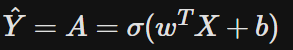

In [29]:
def predict(w, b, X):
  m = X.shape[1]
  Y_prediction = np.zeros((1, m))
  w = w.reshape(X.shape[0], 1)

  A = sigmoid(w.T@X + b) # 시그모이드를 통한 예측값

  for i in range(A.shape[1]):
    Y_prediction[:, i] = (A[:, i] > 0.5) * 1 # 시그모이드 값이 0.5이상인 경우 1 아닌경우 0

  assert(Y_prediction.shape == (1, m))

  return Y_prediction

In [30]:
w = np.array([[0.1124579],[0.23106775]])
b = -0.3
X = np.array([[1.,-1.1,-3.2],[1.2,2.,0.1]])
print ("predictions = " + str(predict(w, b, X)))

predictions = [[1. 1. 0.]]


# 모든함수를 통합하여 모델구현

테스트 오류는 68%입니다.

사실 이 간단한 모델에는 나쁘지 않습니다.

우리가 사용한 데이터셋이 작고 로지스틱 회귀가 선형 분류기라는 점을 고려할 때 말이죠. 하지만 걱정하지 마세요, 다음 주에 더 나은 분류기를 만들 수 있을 거예요!

또한 모델이 학습 데이터에 명백히 과적합되는 것을 볼 수 있습니다.


예를 들어 정규화를 사용하여 과적합을 줄이는 방법을 배우게 됩니다..

### 직접구현

In [39]:
num_iterations = 2000
learning_rate = 0.5

w, b = initialize_with_zeros(train_set_x.shape[0]) # w, b 초기값

# train - w와 b값 구하기
for i in range(num_iterations):
  grads, cost = propagate(w, b, train_set_x, train_set_y) # dw, db 값을 구한다

  w = w - learning_rate * grads['dw']
  b = b - learning_rate * grads['db']



# test
m = test_set_x.shape[1]
Y_predict = np.zeros((1,m))
for t in range(m):
  A = sigmoid(w.T@test_set_x + b)
  Y_predict[:, t] = (A[:, t] > 0.5)


acc = (1 - np.mean(np.abs(test_set_y - Y_predict))) * 100

print("acc:", acc)


<ipython-input-15-2a77c0fcf7d7>:11: RuntimeWarning: divide by zero encountered in log
  cost = -1/m * np.sum(Y*np.log(A) + (1-Y)*(np.log(1-A)))
<ipython-input-15-2a77c0fcf7d7>:11: RuntimeWarning: invalid value encountered in multiply
  cost = -1/m * np.sum(Y*np.log(A) + (1-Y)*(np.log(1-A)))
<ipython-input-11-a8faa0db2be5>:3: RuntimeWarning: overflow encountered in exp
  s = 1 / (1 + np.exp(-z)) # 각요소에 대해 연산


acc: 72.0


In [40]:
def model(X_train, Y_train, X_test, Y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):

    w, b = initialize_with_zeros(X_train.shape[0]) # 초기화

    # Train
    parameters, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost) # 경사하강법

    # 최적화된 w, b값
    w = parameters["w"]
    b = parameters["b"]

    # Test
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)


    # Print train/test Errors
    print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
    print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))


    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test,
         "Y_prediction_train" : Y_prediction_train,
         "w" : w,
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}

    return d

In [43]:
d = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 2000, learning_rate = 0.005, print_cost = True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


y = 1, predict "cat


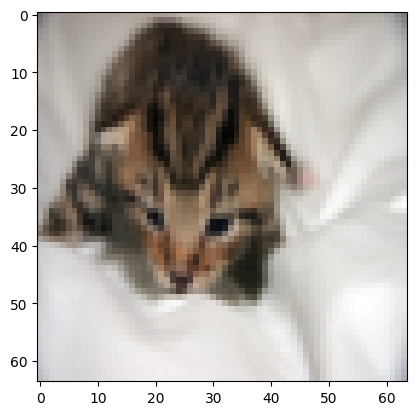

In [72]:
index = 1
newshape = int(np.sqrt(test_set_x.shape[0]/3))
plt.imshow(test_set_x[:,index].reshape((newshape, newshape, 3)))
print ("y = " + str(test_set_y[0,index]) + ", predict \"" + classes[int(d["Y_prediction_test"][0,index])].decode("utf-8"))

# 비용함수 그래프

비용이 감소하는 것을 볼 수 있습니다.

매개변수가 학습되고 있음을 보여줍니다.

그러나 학습 세트에서 모델을 더 많이 학습시킬 수 있다는 것을 알 수 있습니다.

 위의 셀에서 반복 횟수를 늘리고 셀을 다시 실행하세요.

 학습 세트 정확도는 상승하지만 테스트 세트 정확도는 하락하는 것을 볼 수 있습니다.

 이를 "과적합" 이라고 합니다.

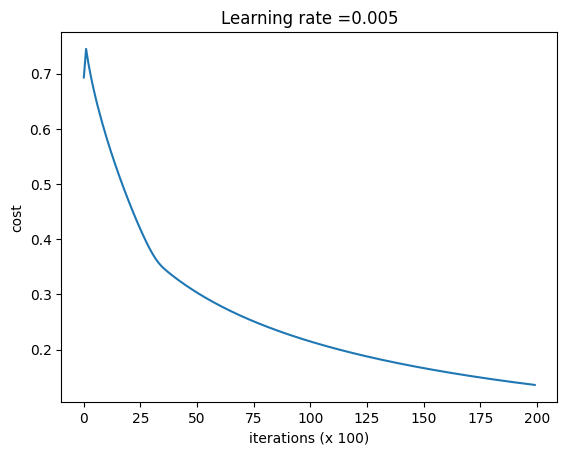

In [74]:
# Plot learning curve (with costs)
costs = np.squeeze(d['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (x 100)')
plt.title("Learning rate =" + str(d["learning_rate"]))
plt.show()

- 학습률 선택

학습률을 현명하게 선택해야 합니다

학습률에 의해 매개변수를 얼마나 빨리 업데이트할지를 결정하게 됩니다

학습률이 너무 크면 최적의 값을 "over shoot"할 수 있습니다.

마찬가지로 학습률이 너무 작으면 최적의 값으로 수렴하기 위해 너무 많은 반복이 필요합니다.

그렇기 때문에 잘 조정된 학습률을 사용하는 것이 중요합니다.

학습 속도에 따라 비용이 달라지므로 예측 결과도 달라집니다.

학습률이 너무 높으면(0.01) 비용이 위아래로 변동할 수 있습니다.

(이 예에서는 0.01을 사용해도 결국 비용 대비 좋은 값이 됩니다)

비용이 낮다고 해서 더 나은 모델이 되는 것은 아닙니다.

과적합이 있는지 확인해야 합니다.

훈련 정확도가 테스트 정확도보다 훨씬 높을 때 발생합니다.

딥러닝에서는 일반적으로 다음과 같은 방법을 권장합니다:

비용 함수를 더 잘 최소화할 수 있는 학습률을 선택하세요.

모델이 과적합되면 다른 기법을 사용하여 과적합을 줄입니다. (이에 대해서는 나중에 동영상에서 설명하겠습니다.)

learning rate is: 0.01
train accuracy: 99.52153110047847 %
test accuracy: 68.0 %

-------------------------------------------------------

learning rate is: 0.001
train accuracy: 88.99521531100478 %
test accuracy: 64.0 %

-------------------------------------------------------

learning rate is: 0.0001
train accuracy: 68.42105263157895 %
test accuracy: 36.0 %

-------------------------------------------------------



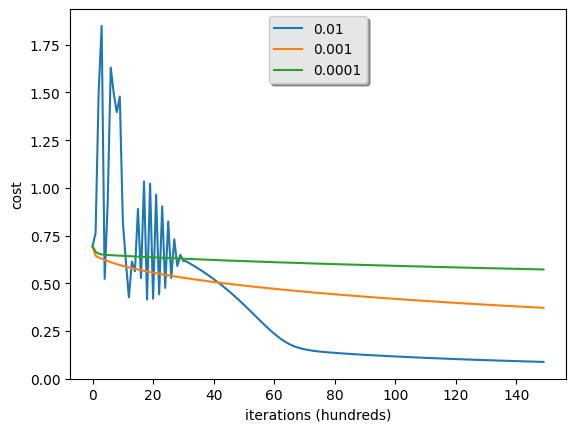

In [75]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}
for i in learning_rates:
    print ("learning rate is: " + str(i))
    models[str(i)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations = 1500, learning_rate = i, print_cost = False)
    print ('\n' + "-------------------------------------------------------" + '\n')

# 학습률에 따른 비용값을 그래프로 그리기
for i in learning_rates:
    plt.plot(np.squeeze(models[str(i)]["costs"]), label= str(models[str(i)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

# 자신의 이미지로 테스트하기

In [ ]:
## START CODE HERE ## (PUT YOUR IMAGE NAME)
my_image = "my_image.jpg"   # change this to the name of your image file
## END CODE HERE ##

# We preprocess the image to fit your algorithm.
fname = "images/" + my_image
image = np.array(ndimage.imread(fname, flatten=False))
my_image = scipy.misc.imresize(image, size=(num_px,num_px)).reshape((1, num_px*num_px*3)).T
my_predicted_image = predict(d["w"], d["b"], my_image)

plt.imshow(image)
print("y = " + str(np.squeeze(my_predicted_image)) + ", your algorithm predicts a \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" picture.")